## 事前準備
このコードを実行する場合は，Google Colab上で，ランタイムをGPUに変更して実行したほうがよい．

【参考】https://colab.research.google.com/github/greentfrapp/lucent-notebooks/blob/master/notebooks/modelzoo.ipynb

In [ ]:
# Install packages
!pip install torch-lucent

In [14]:
# Setup
import torch
import numpy as np
from lucent.optvis import render
from lucent.modelzoo.util import get_model_layers

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def fix_randomness(seed=42):
  """Fixes randomness for PyTorch and NumPy.

  Args:
    seed: The seed to use for the random number generators.
  """
  torch.manual_seed(seed)
  if device != 'cpu':
      torch.cuda.manual_seed_all(seed)  # If using GPU
  np.random.seed(seed)

In [7]:
# Load models
from torchvision.models import googlenet
googlenet_model = googlenet(pretrained=True).to(device).eval()
print('Existing layer names:')
print(', '.join(get_model_layers(googlenet_model)))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Existing layer names:
conv1, conv1_conv, conv1_bn, maxpool1, conv2, conv2_conv, conv2_bn, conv3, conv3_conv, conv3_bn, maxpool2, inception3a, inception3a_branch1, inception3a_branch1_conv, inception3a_branch1_bn, inception3a_branch2, inception3a_branch2_0, inception3a_branch2_0_conv, inception3a_branch2_0_bn, inception3a_branch2_1, inception3a_branch2_1_conv, inception3a_branch2_1_bn, inception3a_branch3, inception3a_branch3_0, inception3a_branch3_0_conv, inception3a_branch3_0_bn, inception3a_branch3_1, inception3a_branch3_1_conv, inception3a_branch3_1_bn, inception3a_branch4, inception3a_branch4_0, inception3a_branch4_1, inception3a_branch4_1_conv, inception3a_branch4_1_bn, inception3b, inception3b_branch1, inception3b_branch1_conv, inception3b_branch1_bn, inception3b_branch2, inception3b_branch2_0, inception3b_branch2_0_conv, inception3b_branch2_0_bn, inception3b_branch2_1, inception3b_branch2_1_conv, inception3b_branch2_1_bn, inception3b_branch3, inception3b_branch3_0, inception3b_b

100%|██████████| 512/512 [00:11<00:00, 46.36it/s]



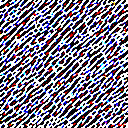

100%|██████████| 512/512 [00:11<00:00, 44.43it/s]



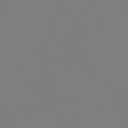

100%|██████████| 512/512 [00:10<00:00, 47.40it/s]



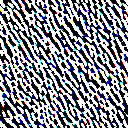

100%|██████████| 512/512 [00:10<00:00, 47.40it/s]



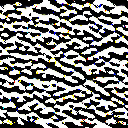

100%|██████████| 512/512 [00:11<00:00, 45.14it/s]



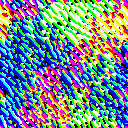

In [15]:
# Try to visualize same channel
fix_randomness()
for i in range(5):
    _ = render.render_vis(googlenet_model, f"maxpool1:{i}", show_inline=True)

100%|██████████| 512/512 [00:13<00:00, 37.90it/s]



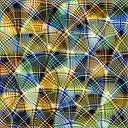

100%|██████████| 512/512 [00:14<00:00, 36.01it/s]



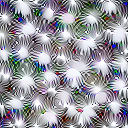

100%|██████████| 512/512 [00:13<00:00, 37.14it/s]



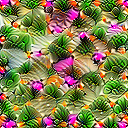

100%|██████████| 512/512 [00:14<00:00, 35.76it/s]



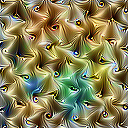

In [16]:
# _ = render.render_vis(googlenet_model, "inception4a:107", show_inline=True) # 集合体でこわいので
# _ = render.render_vis(googlenet_model, "inception4a:106", show_inline=True) # 集合体でこわいので
# _ = render.render_vis(googlenet_model, "inception4a:104", show_inline=True) # ゲジゲジしており少し気持ち悪い
fix_randomness()
units = [103, 0, 1, 2]
for u in units:
    _ = render.render_vis(googlenet_model, f"inception4a:{u}", show_inline=True)

100%|██████████| 512/512 [00:17<00:00, 29.29it/s]



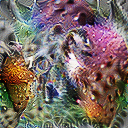

In [19]:
# strawberry label
fix_randomness()
_ = render.render_vis(googlenet_model, "labels:949", show_inline=True)